In [2]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = False


In [3]:
L = 1.0
Nx = 400          
cfl = 0.9         
t_end = 0.30      
dx = L / Nx

x = np.linspace(0, L, Nx, endpoint=False)
u0 = np.sin(2*np.pi*x)

t_shock = 1.0 / (2*np.pi)
t_shock


0.15915494309189535

In [4]:
def flux(u):
    return 0.5 * u**2

def godunov_flux(uL, uR):
    fL = flux(uL)
    fR = flux(uR)
    out = np.empty_like(uL)

    rare = uL <= uR
    mask = rare & (uL > 0)
    out[mask] = fL[mask]
    mask = rare & (uR < 0)
    out[mask] = fR[mask]
    mask = rare & (uL <= 0) & (uR >= 0)
    out[mask] = 0.0

    shock = ~rare
    s = 0.5 * (uL + uR)
    mask = shock & (s > 0)
    out[mask] = fL[mask]
    mask = shock & (s <= 0)
    out[mask] = fR[mask]
    return out

def step_godunov(u, dx, cfl):
    umax = np.max(np.abs(u))
    dt = cfl * dx / umax if umax != 0 else cfl * dx
    uR = np.roll(u, -1)
    uL = np.roll(u, +1)
    F_plus  = godunov_flux(u,  uR)  # at j+1/2
    F_minus = godunov_flux(uL, u )  # at j-1/2
    un = u - (dt/dx) * (F_plus - F_minus)
    return un, dt

def step_lw(u, dx, cfl):
    umax = np.max(np.abs(u))
    dt = cfl * dx / umax if umax != 0 else cfl * dx
    uR = np.roll(u, -1)
    uL = np.roll(u, +1)

    f  = flux(u)
    fR = flux(uR)
    fL = flux(uL)

    # Predictor to half-time at interfaces j±1/2
    u_half_plus  = 0.5*(u + uR) - 0.5*(dt/dx)*(fR - f)
    u_half_minus = 0.5*(uL + u) - 0.5*(dt/dx)*(f  - fL)

    F_plus  = flux(u_half_plus)
    F_minus = flux(u_half_minus)

    un = u - (dt/dx) * (F_plus - F_minus)
    return un, dt


In [5]:

def simulate(u_init, scheme_step, t_end, cfl=0.9, record_times=None):
    u = u_init.copy()
    t = 0.0
    if record_times is None:
        record_times = []
    record_times = sorted(record_times)
    snaps = {}
    rec_idx = 0

    times_hist = [t]
    tv_hist = [np.sum(np.abs(np.roll(u, -1) - u))]

    while t < t_end - 1e-12:
        un, dt = scheme_step(u, dx, cfl)
        if t + dt > t_end:
            scale = (t_end - t) / dt
            u = u + scale * (un - u)
            t = t_end
        else:
            u = un
            t += dt

        times_hist.append(t)
        tv_hist.append(np.sum(np.abs(np.roll(u, -1) - u)))

        while rec_idx < len(record_times) and t >= record_times[rec_idx] - 1e-12:
            snaps[record_times[rec_idx]] = u.copy()
            rec_idx += 1

    return {
        "x": x.copy(),
        "snaps": snaps,
        "times_hist": np.array(times_hist),
        "tv_hist": np.array(tv_hist),
        "u_final": u.copy(),
    }


In [6]:

record_times = [0.00, 0.08, float(t_shock), 0.22, 0.30]

res_upwind = simulate(u0, step_godunov, t_end, cfl=cfl, record_times=record_times)
res_lw     = simulate(u0, step_lw,      t_end, cfl=cfl, record_times=record_times)

record_times


[0.0, 0.08, 0.15915494309189535, 0.22, 0.3]

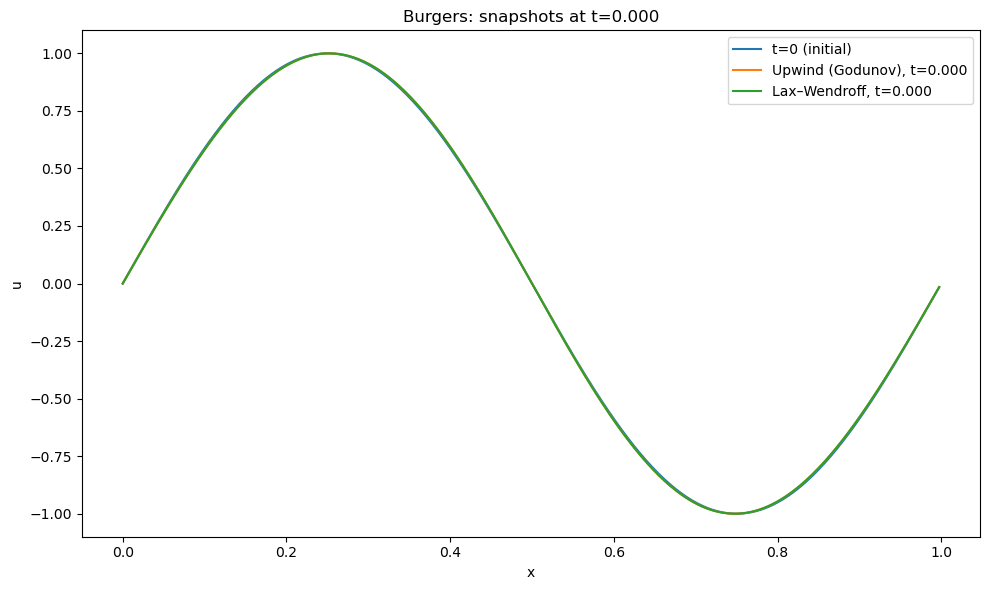

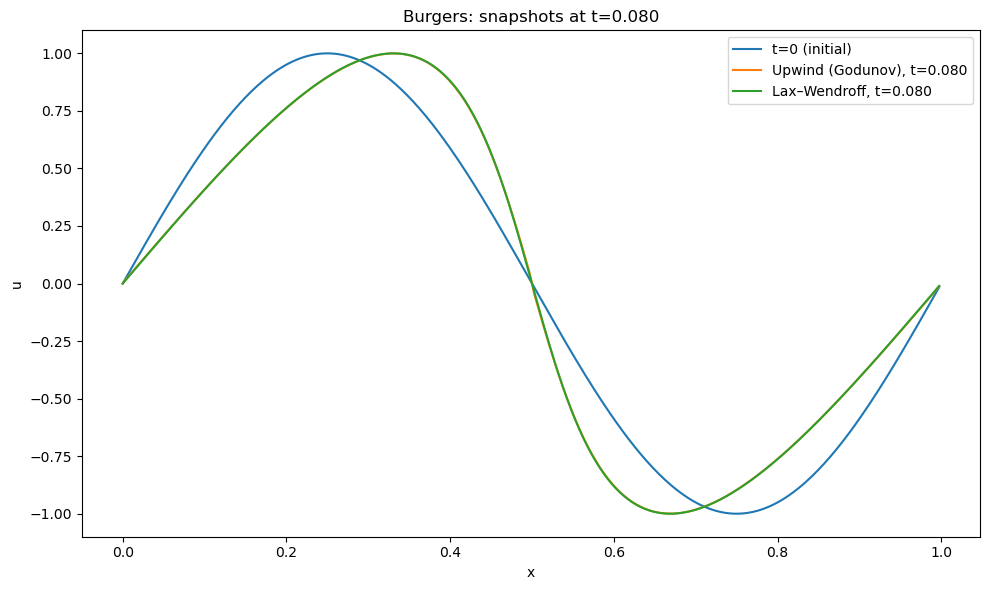

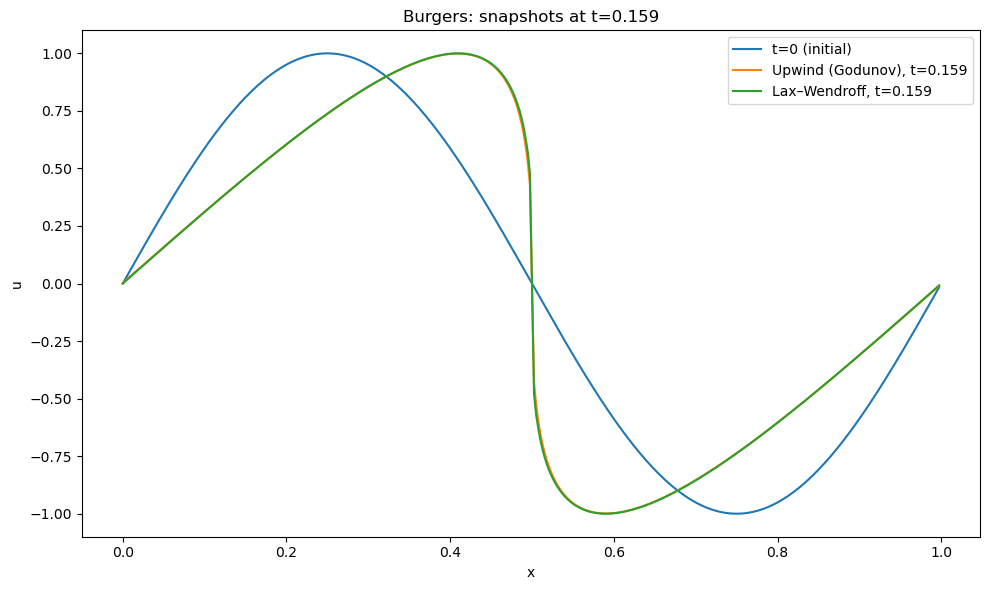

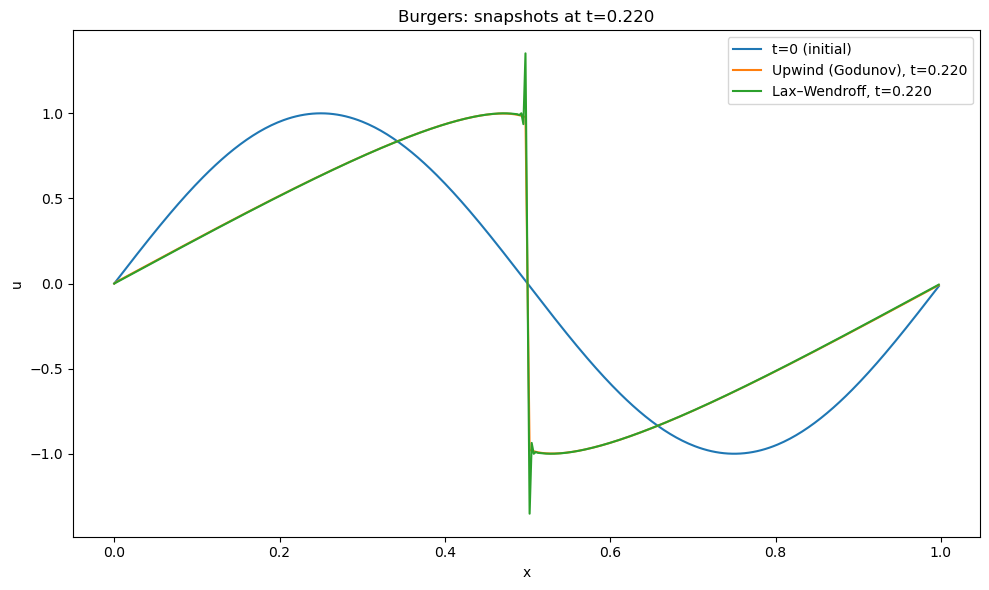

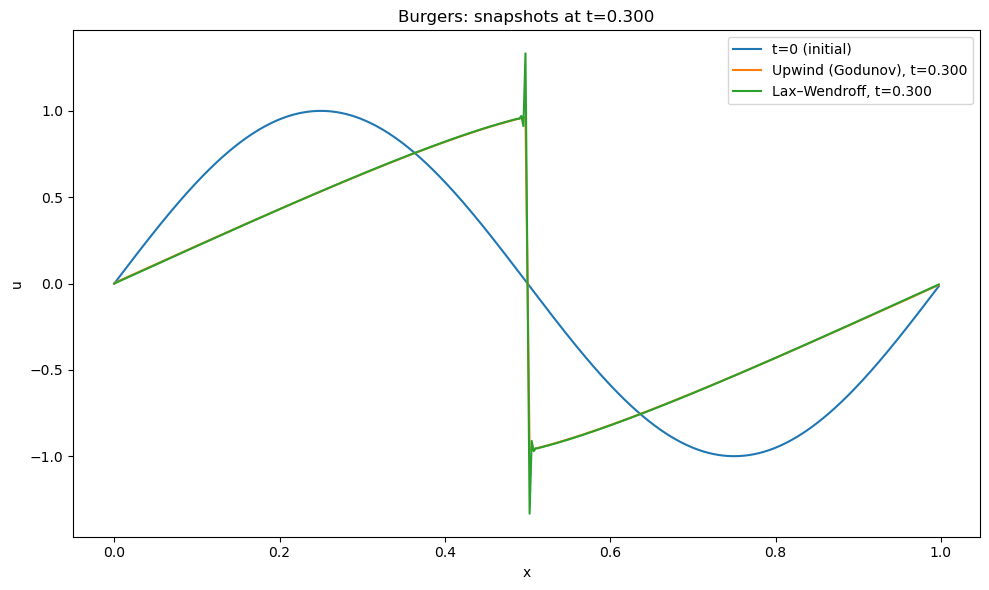

In [7]:

for t_snap in record_times:
    plt.figure()
    plt.plot(res_upwind["x"], u0, label="t=0 (initial)")
    if t_snap in res_upwind["snaps"]:
        plt.plot(res_upwind["x"], res_upwind["snaps"][t_snap], label=f"Upwind (Godunov), t={t_snap:.3f}")
    if t_snap in res_lw["snaps"]:
        plt.plot(res_lw["x"], res_lw["snaps"][t_snap], label=f"Lax–Wendroﬀ, t={t_snap:.3f}")
    plt.title(f"Burgers: snapshots at t={t_snap:.3f}")
    plt.xlabel("x"); plt.ylabel("u")
    plt.legend(); plt.tight_layout(); plt.show()


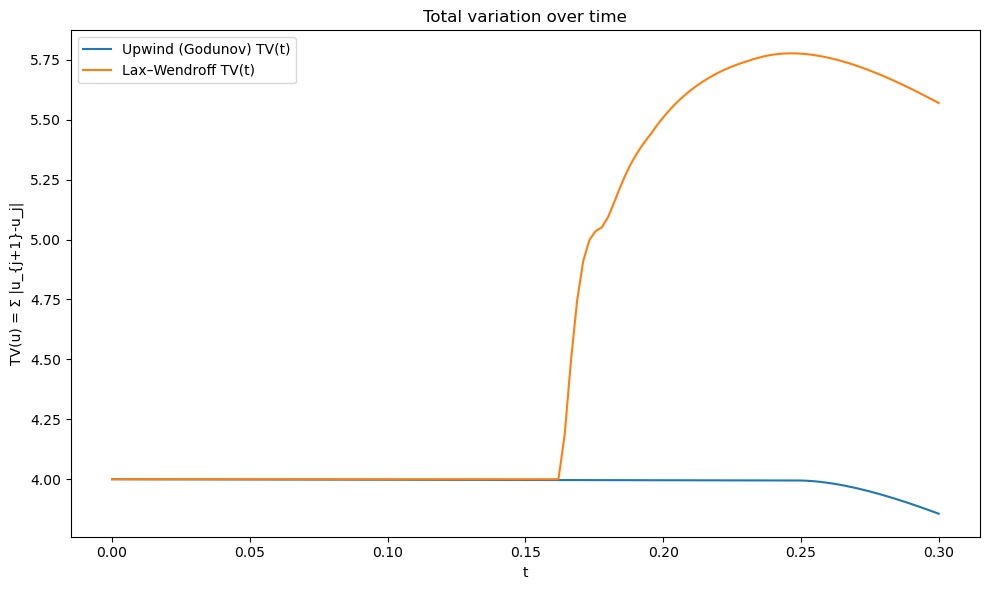

In [8]:

plt.figure()
plt.plot(res_upwind["times_hist"], res_upwind["tv_hist"], label="Upwind (Godunov) TV(t)")
plt.plot(res_lw["times_hist"],     res_lw["tv_hist"],     label="Lax–Wendroﬀ TV(t)")
plt.title("Total variation over time")
plt.xlabel("t"); plt.ylabel("TV(u) = Σ |u_{j+1}-u_j|")
plt.legend(); plt.tight_layout(); plt.show()


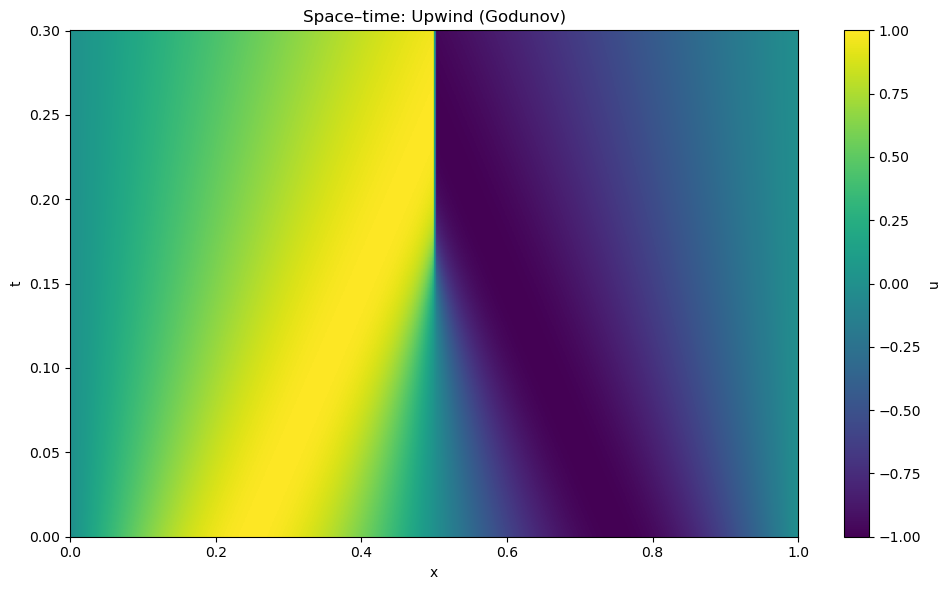

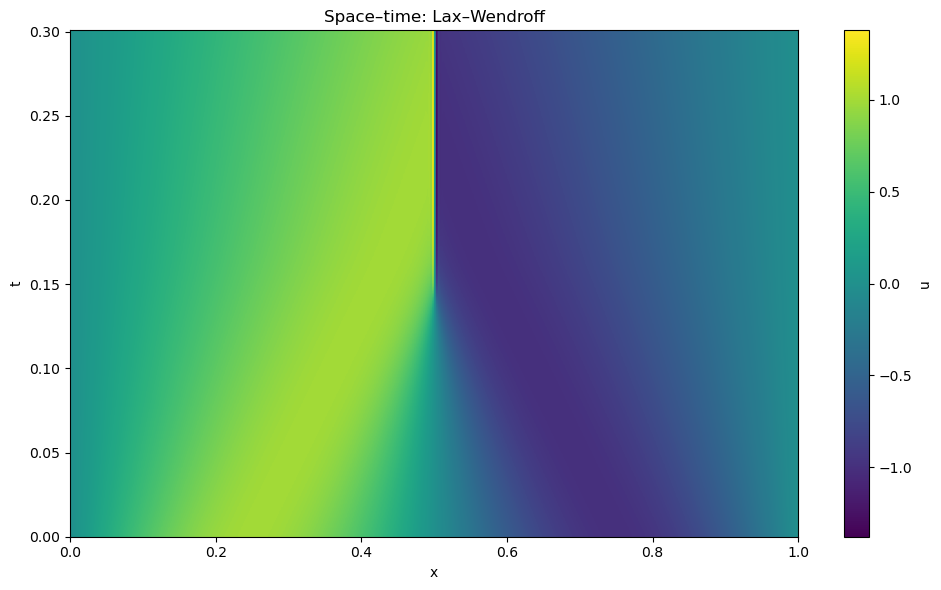

In [9]:

def simulate_collect(u_init, scheme_step, t_end, cfl=0.9, nframes=400):
    u = u_init.copy()
    t = 0.0
    U = [u.copy()]
    ts = [t]
    for _ in range(nframes-1):
        un, dt = scheme_step(u, dx, cfl)
        u = un
        t += dt
        U.append(u.copy())
        ts.append(t)
        if t >= t_end:
            break
    return np.array(ts), np.array(U)

ts_u, U_u = simulate_collect(u0, step_godunov, t_end, cfl=cfl, nframes=400)
ts_l, U_l = simulate_collect(u0, step_lw,      t_end, cfl=cfl, nframes=400)

def spacetime_plot(U, ts, title):
    plt.figure()
    plt.imshow(U, aspect='auto', origin='lower',
               extent=[0, 1, ts[0], ts[len(U)-1]])
    plt.title(title)
    plt.xlabel("x"); plt.ylabel("t")
    plt.colorbar(label="u")
    plt.tight_layout(); plt.show()

spacetime_plot(U_u, ts_u, "Space–time: Upwind (Godunov)")
spacetime_plot(U_l, ts_l, "Space–time: Lax–Wendroﬀ")
